In [20]:
"""
This script generates synthetic 2D images of a star-shaped pattern with varying signal-to-noise ratios (SNRs) 
and corresponding ground truth images. The generated data is saved in HDF5 format for further processing 
(e.g., by a convolutional neural network). Additionally, optional TIFF files and an ImageJ macro can be 
generated for visualization and analysis.

Usage:
    Run the script directly to generate the synthetic data and save it in the specified formats. 
    Uncomment the optional sections to generate TIFF files and an ImageJ macro.
    - The random number generator is fixed with a seed for repeatable executions.
    - The script assumes the working directory is writable for saving the output files.
    - The optional ImageJ macro is used for automated application of ThunderSTORM multi-emitter fitting.
"""

import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy.ndimage as ndi
from psf_toolbox import scaled_psf2, render_psf_emitters, psf_high_NA_2D

# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)

# ------------ Data generation parameters  --------------
MONTE_CARLO_SAMPLES = 10
PSFW = 2
WIDTH = 50
HEIGTH = 50
BCKG = 3
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 45*DEG
snrs = np.logspace(0, 3, 11)

# ------------ Helper functions  --------------

def generate_gt_image(xyi, h, w):
    """
    Generate a ground truth image by placing intensities at specified coordinates.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains three values 
                              (x, y, intensity). `x` and `y` are the coordinates, and 
                              `intensity` is the value to be added at that position.
        h (int): The height of the output image.
        w (int): The width of the output image.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, 
                       normalized such that the sum of all pixel values equals 1.

    Notes:
        - The function rounds the `x` and `y` coordinates to the nearest integer 
          to determine the pixel location.
        - If the rounded coordinates fall outside the image dimensions, they are ignored.
        - The resulting image is normalized by dividing all pixel values by the total sum.
    """
    img = np.zeros((h, w))
    for x, y, intensity in xyi:
        x_nearest = int(np.round(x))
        y_nearest = int(np.round(y))
        if (x_nearest <= w-1) and (y_nearest <= h-1):
            img[y_nearest, x_nearest] += intensity
    return img/np.sum(img)


def upscale_xyi(xyi, scale=4):
    """
    Upscales the x and y coordinates of a list of [x, y, i] elements by a given scale factor.

    This function takes a list of [x, y, i] elements, where x and y are coordinates and i is an 
    additional value, and scales the x and y coordinates by the specified scale factor. A shift 
    is applied to center the scaled coordinates.

    Args:
        xyi (list of lists or tuples): A list of [x, y, i] elements to be upscaled.
        scale (int, optional): The scale factor to upscale the x and y coordinates. Defaults to 4.

    Returns:
        list: A list of upscaled [x, y, i] elements with the same structure as the input.
    """
    xyiarr = np.array(xyi)
    shift = (scale-1)/2
    xyiarr[:, 0] = xyiarr[:, 0]*scale + shift
    xyiarr[:, 1] = xyiarr[:, 1]*scale + shift
    return list(xyiarr)


# ------------ Main part  --------------
# snrs_mc = np.kron(snrs, np.ones(MONTE_CARLO_SAMPLES))
# Generate coordinates of the star-shaped pattern.
# xys = np.array([(25, 25)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25)
#                for i in range(8) for r in [6, 12, 18]])
xyi = np.array([(25,25,1e6)])

In [21]:
au = 580*0.61/1.4 #airy unit
psfhr, x, y = psf_high_NA_2D(256, 8, A_def = 0.05)
psfhr = psfhr[1024-64 : 1024+64, 1024-64 : 1024+64]

img = render_psf_emitters(xyi, 59/au, psfhr, 0.125, 50, 50)
imggt = generate_gt_image(upscale_xyi(xyi), 200, 200)

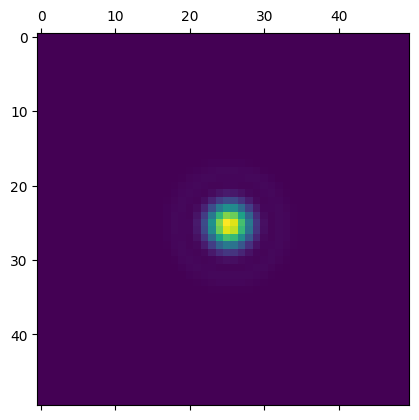

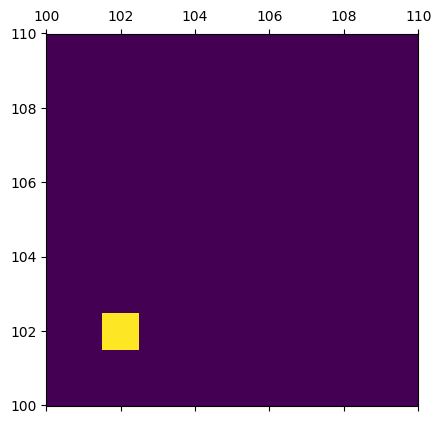

In [22]:
plt.matshow(img)
plt.show()

plt.matshow(imggt)
plt.xlim(100,110)
plt.ylim(100,110)
plt.show()

In [23]:
25*4+1.5

101.5

In [24]:
np.save('single_psf_airy.npy', img)

In [25]:
imgcnn = np.load('single_psf_airy_cnn.npy')[0]

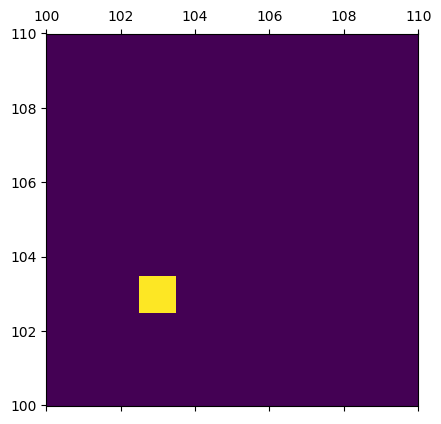

In [26]:
plt.matshow(imgcnn)
plt.xlim(100,110)
plt.ylim(100,110)
plt.show()

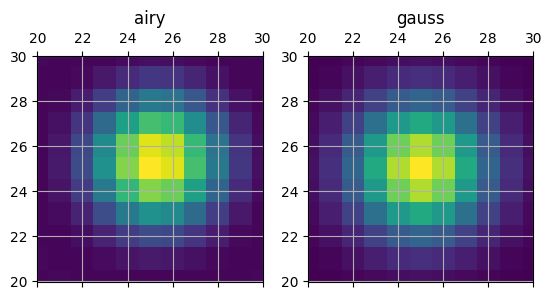

In [33]:
ima = np.load('single_psf_airy.npy')
imb = np.load('single_psf.npy')

fig, ax = plt.subplots(1,2)
ax[0].matshow(ima)
ax[0].set_xlim(20,30)
ax[0].set_ylim(20,30)
ax[0].grid()
ax[1].matshow(imb)
ax[1].set_xlim(20,30)
ax[1].set_ylim(20,30)
ax[1].grid()
ax[0].set_title('airy')
ax[1].set_title('gauss')
plt.show()

In [15]:
def norm(a):
    asu = a - np.min(a)
    norm = np.sum(asu)    
    if norm == 0:
        #for zero-array, skip normalization (to avoid zero-division)
        return np.zeros_like(a)
    return asu/norm
    
def MAE(imA, imB, blur=2):
    imAn = norm(ndi.gaussian_filter(imA, blur))
    imBn = norm(ndi.gaussian_filter(imB, blur))
    return np.mean(np.abs(imAn.ravel() - imBn.ravel()))

def KLD(im_test, im_ref, blur=2, prevent_infty=True):
    imAn = norm(ndi.gaussian_filter(im_test, blur).ravel()) #+ 1e-9 #tested distribution
    if prevent_infty:
        imAn += 1e-10 #this is the value that adds the CNN to dark pixels, this is the typical background value for CNN output
    imBn = norm(ndi.gaussian_filter(im_ref, blur).ravel()) #+ 1e-9 #reference distribution    
    #order here is important, first comes reference
    return entropy(imBn/np.sum(imBn), imAn/np.sum(imAn), base=2)

BLUR = 2
#metrics of interest
metrics = {
    'MAE' : lambda x, y : MAE(x, y, BLUR),
    'KLD' : lambda x, y : KLD(x, y, BLUR)
}

MAE(imgcnn, imggt)

1.3677939281937698e-05

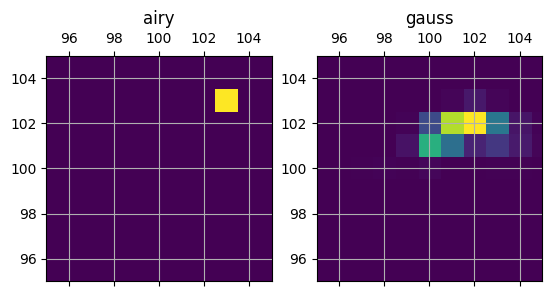

In [32]:
ima = np.load('single_psf_airy_cnn.npy')[0]
imb = np.load('single_psf_cnnout.npy')[0]

fig, ax = plt.subplots(1,2)
ax[0].matshow(ima)
ax[0].set_xlim(95,105)
ax[0].set_ylim(95,105)
ax[0].grid()
ax[1].matshow(imb)
ax[1].set_xlim(95,105)
ax[1].set_ylim(95,105)
ax[1].grid()
ax[0].set_title('airy')
ax[1].set_title('gauss')
plt.show()